# Supplementary Material 1.2 (S1.2): Constraint-Weight Sensitivity

This notebook reproduces the S1.2 plots for the 1D Case I constraint-weight experiments, focusing on how diffusion monotonicity and bound penalties affect optimisation stability and the learned diffusion dynamics.

The notebook contains:

1. A monotonicity-weight sweep over `D_mono_weight` $\lambda_{\partial D} \in \{10, 10^3, 10^4, 10^6\}$  and  at fixed architecture $W_u \in \{16, 64\}, W_D=2, ES=1000$ for the Case I diffusion setting.
2. Diffusion-evolution comparisons across training epochs for each monotonicity-weight choice.
3. Combined `(D_bound_weight, D_mono_weight) = (1e4, 1e4)` and `(D_bound_weight, D_mono_weight) = (0, 0)` settings tested

*It produces Figs. S2-S4 in the supplementary material.*

In [2]:
import copy
import os
import sys
from pathlib import Path

import numpy as np

PROJECT_ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "Training").is_dir()
)
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from Training.JN.notebook_helpers.notebook_config import (
    BCbool,
    BNdataLossFuncLabel,
    D_one_param_bool,
    binn_batch_size,
    binn_lr,
    binn_model_num,
    binn_rel_save_thresh,
    binn_rel_update_thresh,
    binnDevice,
    binnGenerateIndicesLabel,
    binnVF,
)
from Training.JN.notebook_helpers.notebook_data import build_catalog, load_data_object, load_original_data
from Training.JN.notebook_helpers.notebook_models import (
    active_constraint_settings,
    build_model_catalog,
    filter_model_catalog,
    load_requested_models,
    resolve_model_path_from_catalog,
)
from Training.JN.notebook_helpers.notebook_setup import bootstrap_notebook, register_notebook_pickle_globals

paths = bootstrap_notebook(PROJECT_ROOT)
PROJECT_ROOT = paths.project_root
JN_ROOT = paths.notebook_root
DATA_ROOT = paths.data_root
BINN_ROOT = paths.binn_root

register_notebook_pickle_globals()

from paper_helpers import (
    condense_df,
    scale_function_by_percent_error,
    plot_adam_D_diagnostics,
    plot_diffusion_across_epochs,
    plot_initial_condition_1d,
    plot_running_min_MSE_diff_loss_broken_x_log_lst,
    plot_running_min_loss_component_broken_x_log_lst,
)

## 1. Load the S1.2 data

Load the Case I reaction-diffusion dataset and verify that the expected data object is available on disk before generating any comparison panels. The spatial and temporal grids follow [Lagergren et al. (2020)](https://doi.org/10.1371/journal.pcbi.1008462)

MSE between u and u_clean: 0.0
ABS between u and u_clean [cells]: 0.0
ABS (%) between u and u_clean: 0.0


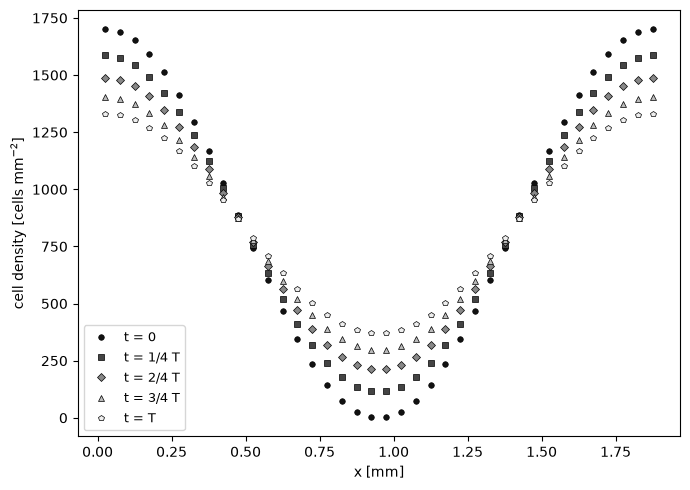

In [3]:
# Load data object from Lagergren et al. (2020)
# ============================================
data_orig_obj_FKPP = load_original_data(DATA_ROOT)
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1

data_df = build_catalog(DATA_ROOT, target_filename="data_obj.npy")

xNum = len(x)
tNum = len(t)
gamma = 0
noise_percent = 0
IC_label = "cos"
seed = 0
diff_label = "const"
grow_label = "zero"
dataX2num = 1

CASE1_DATA_CONFIG = {
    "dataX1num": xNum,
    "dataX2num": 1,
    "dataTnum": tNum,
    "dataK": K,
    "dataICLabel": IC_label,
    "dataDiffLabel": diff_label,
    "dataGrowLabel": grow_label,
    "dataGamma": gamma,
    "dataNoisePercent": noise_percent,
    "dataNoiseSeed": seed,
}

data_obj, data_df_updated = load_data_object(CASE1_DATA_CONFIG, DATA_ROOT, data_df=data_df)
plot_initial_condition_1d(data_obj)

## 2. Build the S1.2 model catalogue & form helper functions for model loading and plotting

### 2.1. Catalogue trained model

Catalogue the matching `binn` checkpoints for the Case I setting, filter them to the fixed constraint-weight assumptions, and display the training runs available for the weight-sensitivity analysis.

In [4]:
# data frame containing all BINN models across all cases
binn_df = build_model_catalog(BINN_ROOT)

# Notebook-specific constraint-weight settings (not shared via notebook_config).
D_bound_weight = 0
D_mono_weight = 1e4
ALL_CONSTRAINTS = True
CONSTRAINT_TUPLE = (True, True, False, False)
CONSTRAINT_WEIGHTS = {
    "D_bound_weight": D_bound_weight,
    "D_mono_weight": D_mono_weight,
    "G_bound_weight": 1e4,
    "G_mono_weight": 1e4,
}
CONSTRAINT_BOUNDS = {
    "D_bound": (0, 0.1),
    "G_bound": (-0.02 / (1 / 24), 0.1 / (1 / 24)),
}
S12_NUM_PDE_SAMPLES = 100
FIXED_G_WIDTH = None

fixed_filters = CASE1_DATA_CONFIG | {
    "binnVF": binnVF,
    "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
    "binnGsize": FIXED_G_WIDTH,
    "DoneParamBool": D_one_param_bool,
    "binnDevice": binnDevice,
    "allConstraints": ALL_CONSTRAINTS,
    "BCbool": BCbool,
    "numPDEsamples": S12_NUM_PDE_SAMPLES,
    "binnLR": binn_lr,
    "binnBatchSize": binn_batch_size,
    "binnRelUpdateThresh": binn_rel_update_thresh,
    "binnRelSaveThresh": binn_rel_save_thresh,
    "BNdataLossFuncLabel": BNdataLossFuncLabel,
}
if ALL_CONSTRAINTS:
    fixed_filters |= active_constraint_settings(CONSTRAINT_TUPLE, CONSTRAINT_WEIGHTS, CONSTRAINT_BOUNDS)

binn_df1 = filter_model_catalog(
    binn_df,
    fixed_filters,
    empty_message="No updated BINN models found for the Case1 configuration.",
)
binn_df1

,full_path,dataX1num,dataX2num,dataTnum,dataK,dataICLabel,dataDiffLabel,dataGrowLabel,dataGamma,dataNoisePercent,...,binnRelSaveThresh,binnES,binnModelLabel,path_dict,surface_weight,pde_weight,binnActivation,perfectPDE,binnSurfaceHiddenLayers,binnDGHiddenLayers
0,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,zero,0,0,...,0.05,1000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN
1,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,zero,0,0,...,0.05,1000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN
2,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,zero,0,0,...,0.05,1000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN
3,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,zero,0,0,...,0.05,1000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN
4,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,zero,0,0,...,0.05,1000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN
5,/Users/willa954/Desktop/Git-personal/Hyperpara...,38,1,5,1,cos,const,zero,0,0,...,0.05,1000,0,"{'dataX1num': '38', 'dataX2num': '1', 'dataTnu...",NaN,NaN,NaN,NaN,NaN,NaN


### 2.2. Helper functions for loading trained models

In [5]:
# ========================= Dynamic variables for models in case 1 =========================
binn_ES_list = [1000]
binnSplitSeeds = [0, 1, 2]
u_NN_lst = [16, 64]
D_NN_lst = [2]
varyD_ES = 2000
D_NN_chosen = D_NN_lst[0]


def build_case1_model_path(
    D_NN,
    u_NN,
    binnSplitSeed,
    binn_ES,
    *,
    fixed_filters_override=None,
    model_df_override=None,
):
    return resolve_model_path_from_catalog(
        model_df_override if model_df_override is not None else binn_df1,
        fixed_filters_override if fixed_filters_override is not None else fixed_filters,
        {
            "binnTVsplitSeed": binnSplitSeed,
            "binnUsize": u_NN,
            "binnDsize": D_NN,
            "binnES": binn_ES,
        },
        model_label=binn_model_num,
    )


def load_case1_models(
    es_values,
    d_sizes,
    u_sizes,
    split_seeds,
    *,
    fixed_filters_override=None,
    model_df_override=None,
):
    requested_models = []
    for binn_ES in es_values:
        for D_NN in d_sizes:
            for u_NN in u_sizes:
                for binnSplitSeed in split_seeds:
                    requested_models.append(
                        {
                            "binnES": binn_ES,
                            "binnDsize": D_NN,
                            "binnUsize": u_NN,
                            "binnTVsplitSeed": binnSplitSeed,
                            "path": build_case1_model_path(
                            D_NN,
                            u_NN,
                            binnSplitSeed,
                            binn_ES,
                            fixed_filters_override=fixed_filters_override,
                            model_df_override=model_df_override,
                        ),
                        }
                    )
    return load_requested_models(
        requested_models,
        device=binnDevice,
        group_keys=("binnES", "binnDsize", "binnUsize", "binnTVsplitSeed"),
        missing="ignore",
    )


binn_models_by_ES = load_case1_models(
    es_values=binn_ES_list,
    d_sizes=D_NN_lst,
    u_sizes=u_NN_lst,
    split_seeds=binnSplitSeeds,
)


### 2.3 Shared plotting style

Define the publication styling, shared plotting utilities, and canonical output directories used by the supplementary figure panels.

In [6]:
BLUE_COLORS = [
    "#0033A0",
    "#1E90FF",
    "#6699CC",
    "#A4C8E1",
    "#D6EAF8",
]

D_COLORS = [
    "#8B2500",
    "#FF7F0E",
    "#FDB863",
    "#FDD9B5",
    "#FFF1E0",
]

linestyles = ["-"] * 5
MARKER_STYLES = ["o"] * 5
hatch_patterns = ("////", "....", "ooo", "***")


AXIS_FONTSIZES = {
    "xaxis": 18,
    "xtick_labels": 18,
    "yaxis": 18,
    "ytick_labels": 18,
}
LEGEND_SIZE = 18
LEGEND_SIZE_SMALL = 14
figsize = (7, 5)
minEpoch = 0


maxEpoch = 1.2e4
breakEpoch = 2e2
epochAxis = {"min": minEpoch, "max": maxEpoch, "break": breakEpoch}


# plotting styles
def plot_params_from_models(models_dics, colors):
    labels = [str(key) for key in models_dics.keys()]
    return {
        key: [colors[i], linestyles[i], MARKER_STYLES[i], labels[i]]
        for i, key in enumerate(models_dics.keys())
    }

# ground truth diffusion function for case 1 (constant diffusion)
def ground_truth_diffusion(u):
    return data_obj.theta_D * np.ones_like(u)

# form MSE reference values for the case 1 diffusion function
rawMSEs = [0.25, 0.5, 1]
mses = [scale_function_by_percent_error(ground_truth_diffusion, beta=mse)[1] for mse in rawMSEs]


# Plotting directories
# ====================
name_intro_figS3 = JN_ROOT / "pngs" / "1D" / "case1" / "figS3"
os.makedirs(name_intro_figS3, exist_ok=True)
name_intro_figS4 = JN_ROOT / "pngs" / "1D" / "case1" / "figS4"
os.makedirs(name_intro_figS4, exist_ok=True)
name_intro_figS2 = (
    JN_ROOT / "pngs" / "1D" / "case1" /"figS2"
)
os.makedirs(name_intro_figS2, exist_ok=True)

## 3. Figure S3: monotonicity-weight sweep

Generate the validation-loss, diffusion-MSE, and diffusion-monotonicity diagnostic panels across the chosen `D_mono_weight` values.

SORTED ['16', '64']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_a_1.png


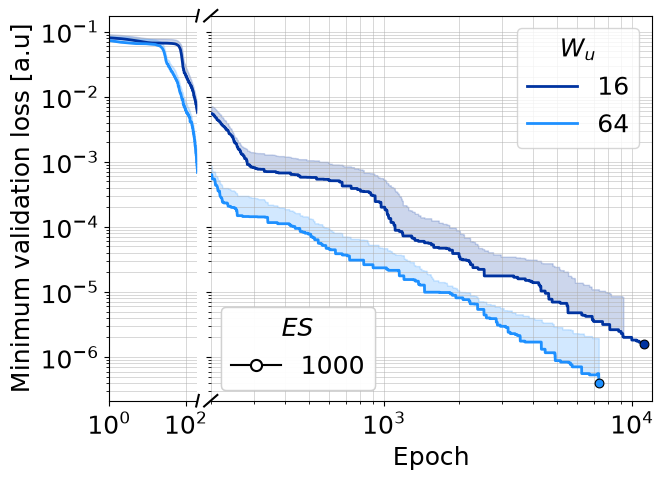

Finished plotting validation loss for D_mono_weight=10


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_a_2.png


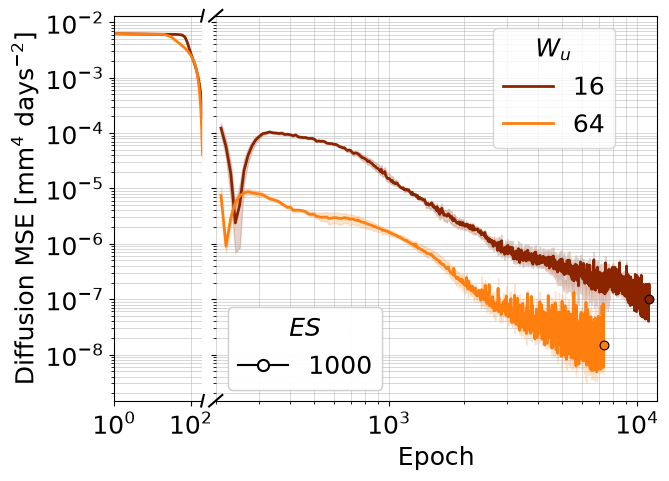

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_adam_diagnostics.py:992: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_a_3_D_mono.png


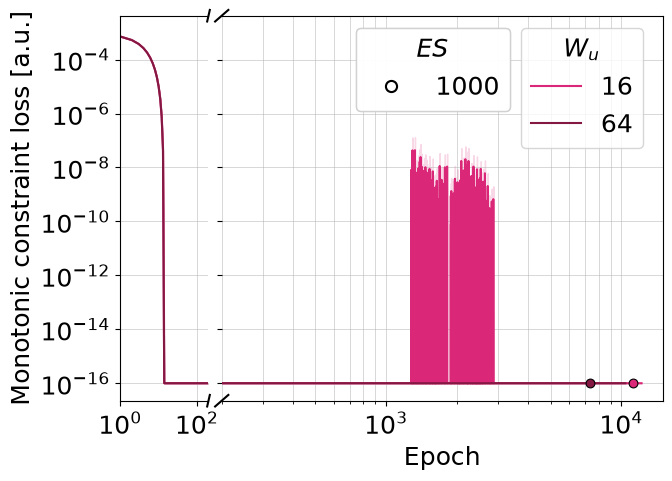

SORTED ['16', '64']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_b_1.png


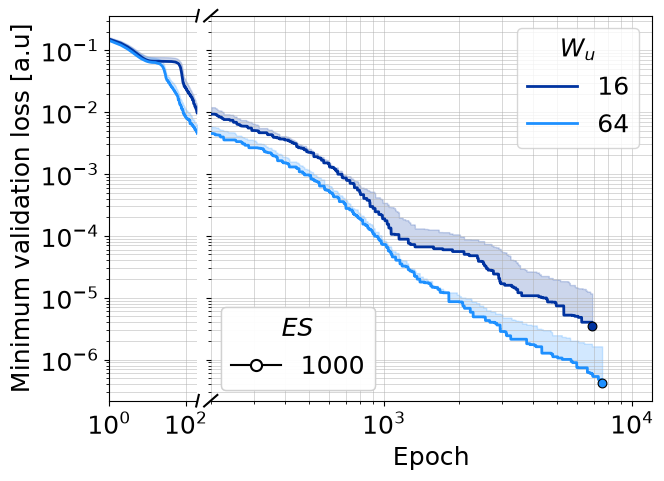

Finished plotting validation loss for D_mono_weight=1000.0


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_b_2.png


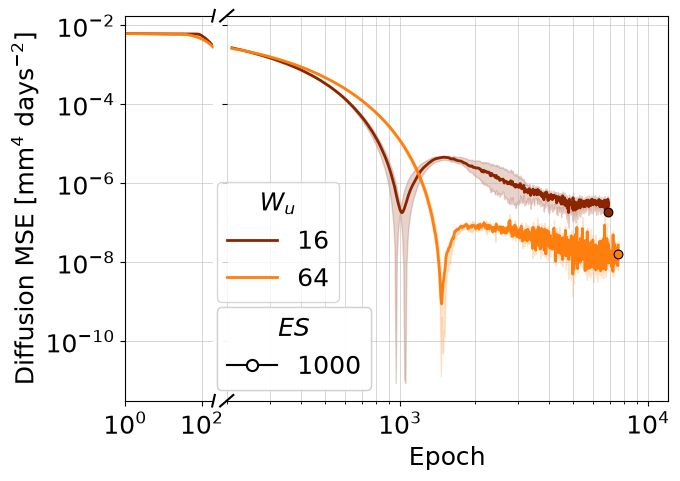

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_adam_diagnostics.py:992: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_b_3_D_mono.png


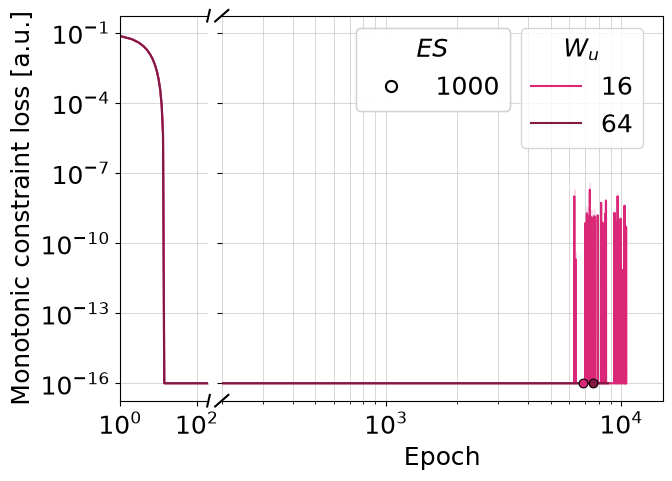

SORTED ['16', '64']
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_c_1.png


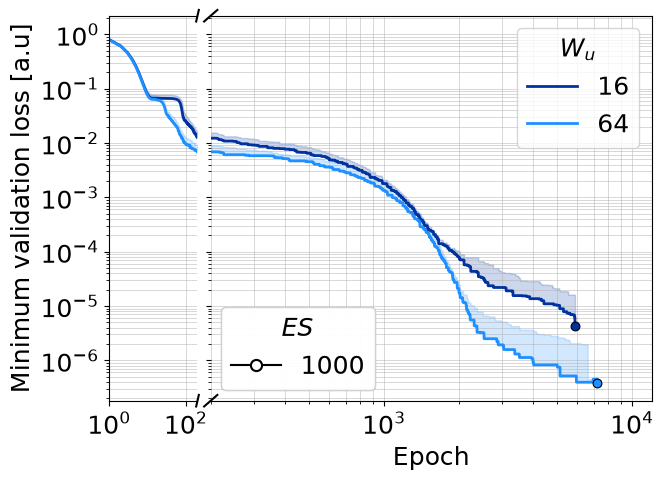

Finished plotting validation loss for D_mono_weight=10000.0
saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_c_2.png


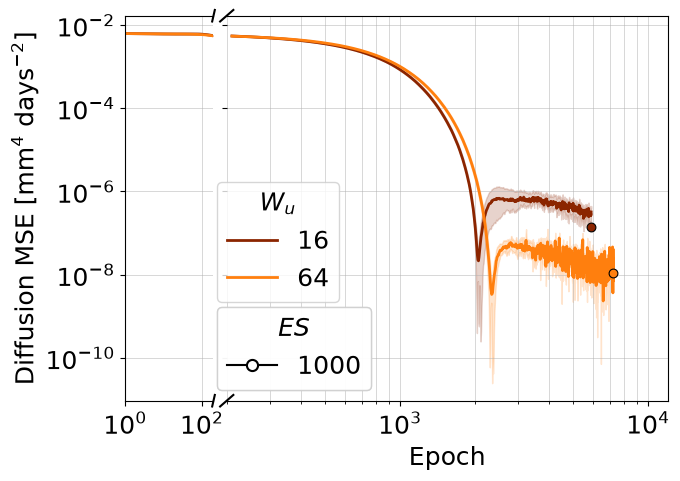

saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_c_3_D_mono.png


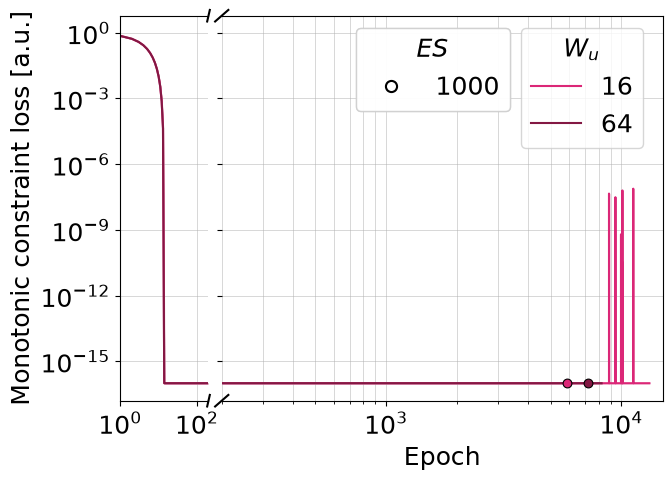

SORTED ['16', '64']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_d_1.png


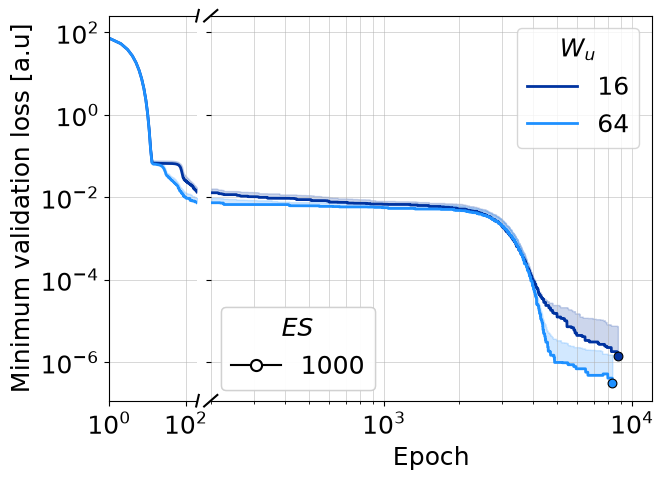

Finished plotting validation loss for D_mono_weight=1000000.0


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_mse_running_min.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_d_2.png


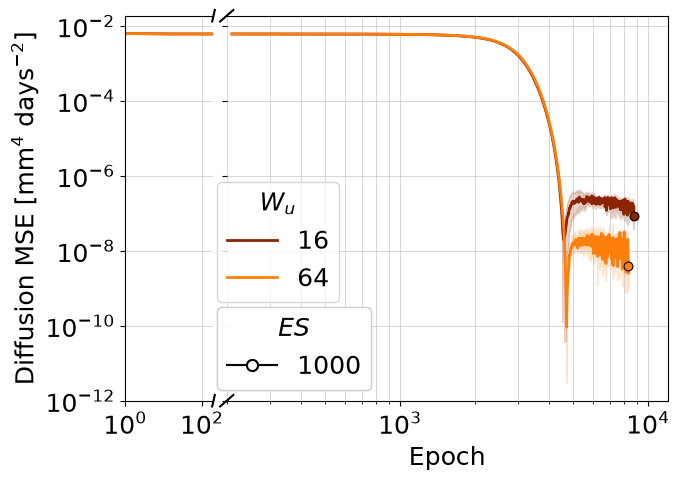

/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_adam_diagnostics.py:992: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS3/plot_d_3_D_mono.png


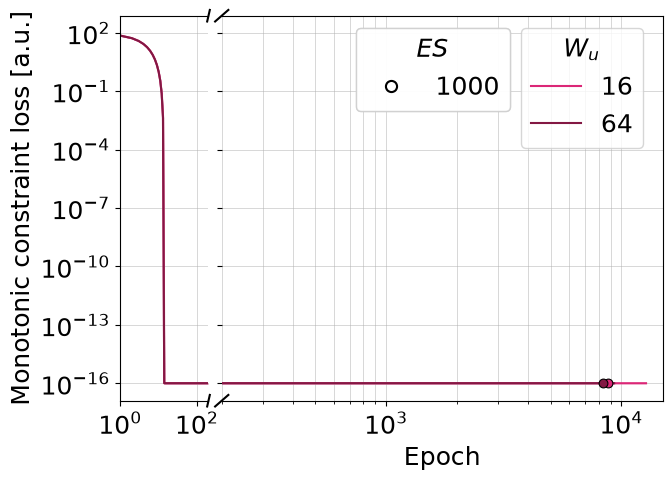

In [7]:
# Figure S3: validation, diffusion-MSE, and D-mono diagnostics across monotonicity-weight choices.
D_mono_weight_values = [10, 1e3, 1e4, 1e6]


def load_models_for_D_mono_weight(D_mono_weight_case):
    if D_mono_weight_case == D_mono_weight:
        return binn_models_by_ES

    constraint_weights_case = {
        "D_bound_weight": D_bound_weight,
        "D_mono_weight": D_mono_weight_case,
        "G_bound_weight": CONSTRAINT_WEIGHTS["G_bound_weight"],
        "G_mono_weight": CONSTRAINT_WEIGHTS["G_mono_weight"],
    }

    fixed_filters_case = {
        "dataX1num": xNum,
        "dataX2num": dataX2num,
        "dataTnum": tNum,
        "dataK": K,
        "dataICLabel": IC_label,
        "dataDiffLabel": diff_label,
        "dataGrowLabel": grow_label,
        "dataGamma": gamma,
        "dataNoisePercent": noise_percent,
        "dataNoiseSeed": seed,
        "binnVF": binnVF,
        "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
        "binnGsize": FIXED_G_WIDTH,
        "DoneParamBool": D_one_param_bool,
        "binnDevice": binnDevice,
        "allConstraints": ALL_CONSTRAINTS,
        **({"constraintTuple": CONSTRAINT_TUPLE} if ALL_CONSTRAINTS else {}),
        **({
            key: constraint_weights_case[key]
            for enabled, key in zip(
                CONSTRAINT_TUPLE,
                ("D_bound_weight", "D_mono_weight", "G_bound_weight", "G_mono_weight"),
            )
            if enabled
        } if ALL_CONSTRAINTS else {}),
        **({
            key: CONSTRAINT_BOUNDS[key]
            for enabled, key in zip(
                CONSTRAINT_TUPLE,
                ("D_bound", None, "G_bound", None),
            )
            if enabled and key is not None
        } if ALL_CONSTRAINTS else {}),
        "BCbool": BCbool,
        "numPDEsamples": S12_NUM_PDE_SAMPLES,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelUpdateThresh": binn_rel_update_thresh,
        "binnRelSaveThresh": binn_rel_save_thresh,
    }

    binn_df_case = condense_df(binn_df, fixed_filters_case)
    if binn_df_case.empty:
        raise ValueError(
            f"No BINN models found for D_mono_weight={D_mono_weight_case}."
        )

    return load_case1_models(
        es_values=binn_ES_list,
        d_sizes=D_NN_lst,
        u_sizes=u_NN_lst,
        split_seeds=binnSplitSeeds,
        fixed_filters_override=fixed_filters_case,
        model_df_override=binn_df_case,
    )

col1labels = ["a_1", "b_1", "c_1", "d_1"]
col2labels = ["a_2", "b_2", "c_2", "d_2"]
col3labels = ["a_3", "b_3", "c_3", "d_3"]

for D_mono_weight_case, col1label, col2label, col3label in zip(D_mono_weight_values, col1labels, col2labels, col3labels):
    binn_models_by_ES_case = load_models_for_D_mono_weight(D_mono_weight_case)

    varyES_models_chosen_ES = binn_models_by_ES_case[binn_ES_list[0]]
    varyES_models_chosen_D = varyES_models_chosen_ES[D_NN_chosen]
    varyES_models_by_ES_chosen_D = [
        binn_models_by_ES_case[ES][D_NN_chosen] for ES in binn_ES_list
    ]
    plot_params_val = plot_params_from_models(
        varyES_models_chosen_D,
        BLUE_COLORS,
    )
    plot_params_diff = plot_params_from_models(
        varyES_models_chosen_D,
        D_COLORS,
    )

    plot_settings_val = {
        "name": str(
            name_intro_figS3
            / f"plot_{col1label}.png"
        ),
        "fill": True,
        "line_width": 2,
        "legend": {
            "panel": 2,
            "loc": (1, 1),
            "loc_upd": (0.4, 0.275),
            "fontsize": LEGEND_SIZE,
            "ncols": 1,
            "marker_title": r"$ES$",
        },
        "xaxis": epochAxis,
        "fontsizes": AXIS_FONTSIZES,
        "figsize": figsize,
        "ylabel": "Minimum validation loss [a.u]",
        "es_entries": [(str(binn_ES_list[0]), "o")],
    }

    plot_running_min_loss_component_broken_x_log_lst(
        models_dics_list=varyES_models_by_ES_chosen_D,
        loss_attr="val_loss_list",
        plot_params=plot_params_val,
        plot_settings=plot_settings_val
    )
    print(f"Finished plotting validation loss for D_mono_weight={D_mono_weight_case}")

    plot_settings_diff = {
        "name": str(
            name_intro_figS3
            / f"plot_{col2label}.png"
        ),
        "fill": True,
        "line_width": 2,
        "legend": {
            "panel": 2,
            "loc": (0.6,1) if D_mono_weight_case == 10 else (-0.05, 0.6),
            "loc_upd": (0.0, 0.275) if D_mono_weight_case == 10 else (-0.05, 0.275),
            "fontsize": LEGEND_SIZE,
            "ncols": 1,
            "marker_title": r"$ES$",
        },
        "xaxis": epochAxis,
        "fontsizes": AXIS_FONTSIZES,
        "figsize": figsize,
        "ylabel": "Minimum validation loss [a.u]",
        "es_entries": [(str(binn_ES_list[0]), "o")],
    }

    plot_running_min_MSE_diff_loss_broken_x_log_lst(
        models_dics_list=varyES_models_by_ES_chosen_D,
        plot_params=plot_params_diff,
        plot_settings=plot_settings_diff,
    )


    plot_settings_diagnostics_base = {
        "name": str(
            name_intro_figS3
            / f"plot_{col3label}.png"
        ),
        "legend": {
            "panel": 2,
            "loc": (0.65, 1),
            "loc_upd": (0.275, 1),
            "fontsize": LEGEND_SIZE,
            "ncols": 1,
            "marker_title": r"$ES$",
        },
        "x_max": 15000,
        "components": [{"name": "D_mono", "palette": ("#DB2777", "#831843")}],
        "xaxis": epochAxis,
        "xscale": "log",
        "fontsizes": AXIS_FONTSIZES,
        "es_entries": [(str(binn_ES_list[0]), "o")],
        "ylabel": "Monotonic constraint loss [a.u.]"
    }

    plot_adam_D_diagnostics(
        models_dics=varyES_models_by_ES_chosen_D[0],
        plot_settings=plot_settings_diagnostics_base,
    )




## 4. Figure S4: diffusion evolution across training epochs

Compare how the learned diffusion field evolves over training for each monotonicity-weight setting and network width.

============================================================== 10 ============================================================== 
-------------------------- Wu = 16 --------------------------- 
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_10_diffusion_group_1_model0_ylim_0p015_0p11.png


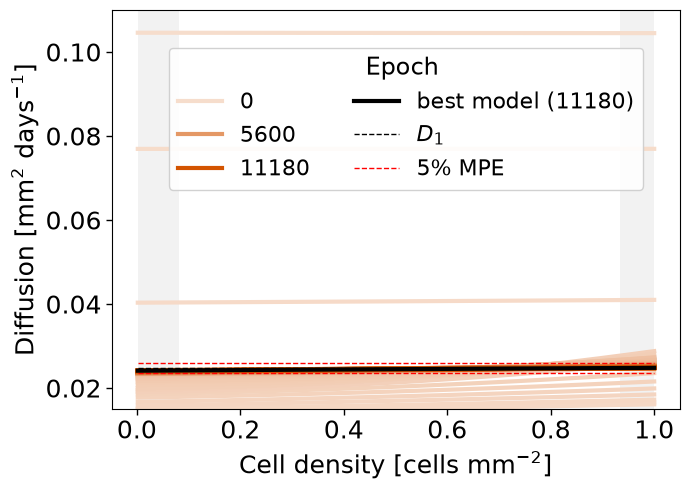

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_10_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_10_diffusion_group_1_model0_ylim_0p0234_0p026.png


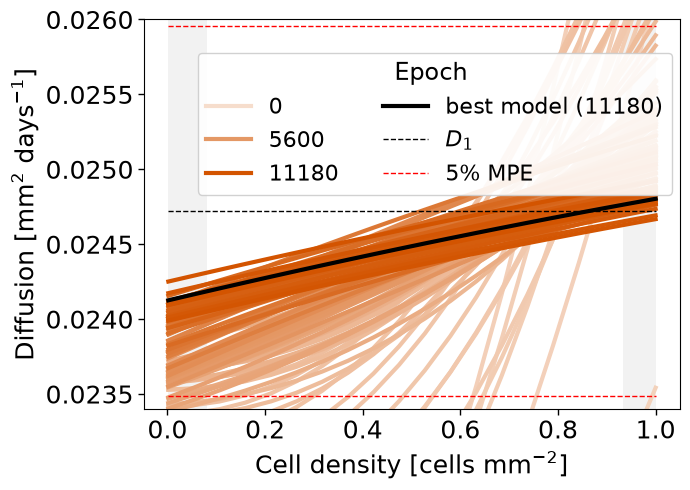

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_10_diffusion_group_1_model0_ylim_0p0234_0p026.png
-------------------------- Wu = 64 --------------------------- 
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_10_diffusion_group_1_model0_ylim_0p015_0p11.png


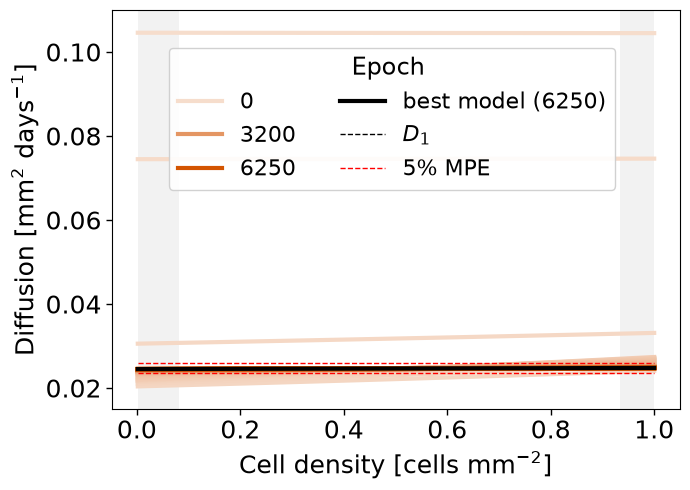

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_10_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_10_diffusion_group_1_model0_ylim_0p0234_0p026.png


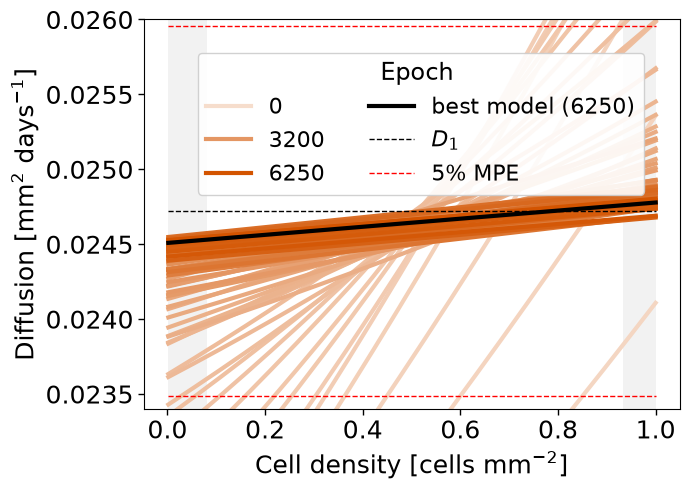

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_10_diffusion_group_1_model0_ylim_0p0234_0p026.png
============================================================== 1000.0 ============================================================== 
-------------------------- Wu = 16 --------------------------- 
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_1000.0_diffusion_group_1_model0_ylim_0p015_0p11.png


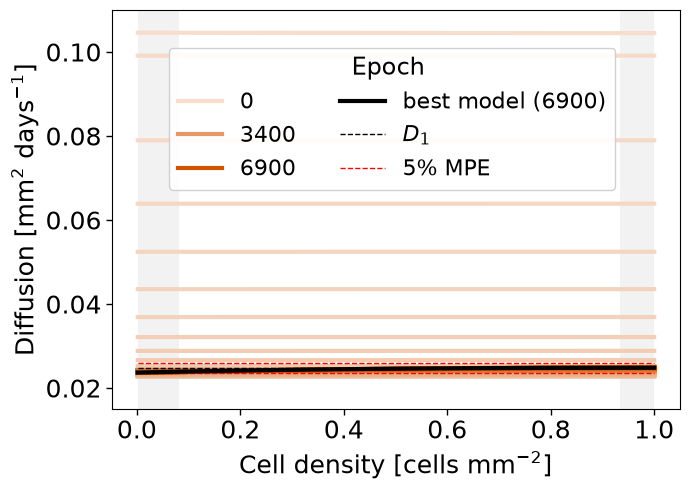

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_1000.0_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_1000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png


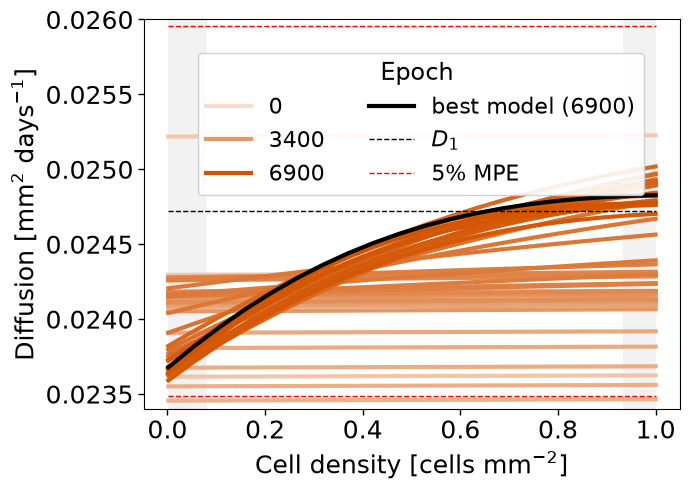

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_1000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png
-------------------------- Wu = 64 --------------------------- 
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_1000.0_diffusion_group_1_model0_ylim_0p015_0p11.png


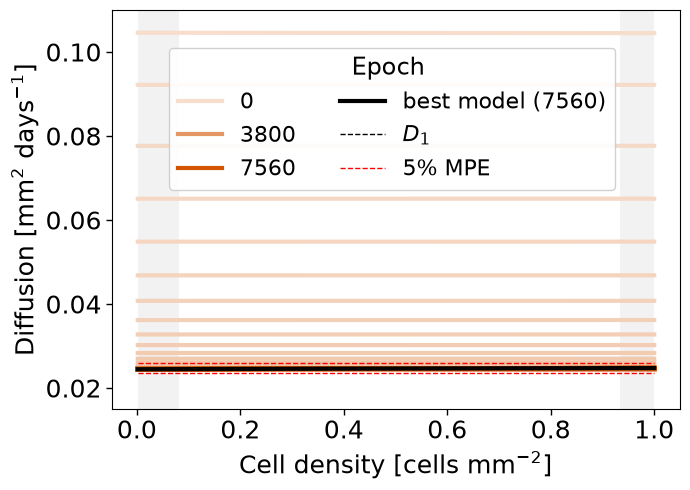

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_1000.0_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_1000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png


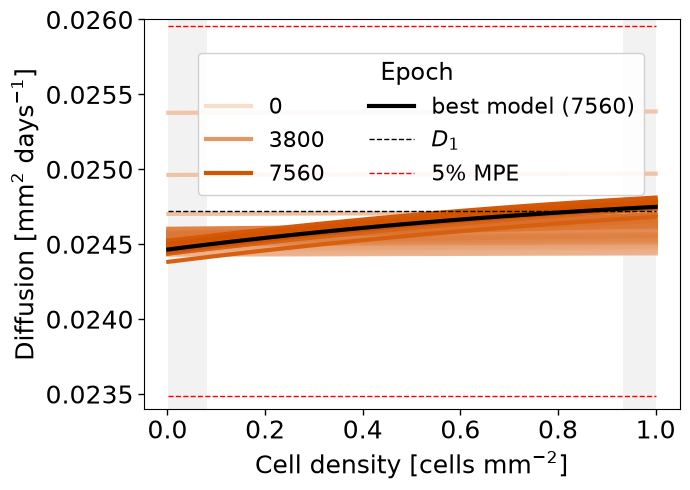

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_1000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png
============================================================== 10000.0 ============================================================== 
-------------------------- Wu = 16 --------------------------- 
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_10000.0_diffusion_group_1_model0_ylim_0p015_0p11.png


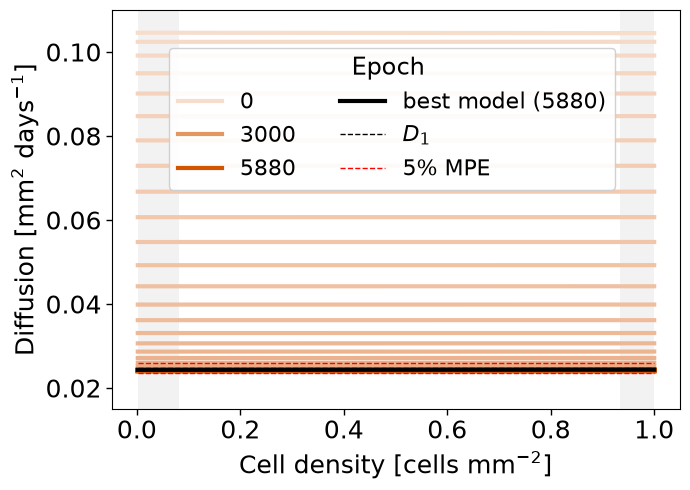

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_10000.0_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_10000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png


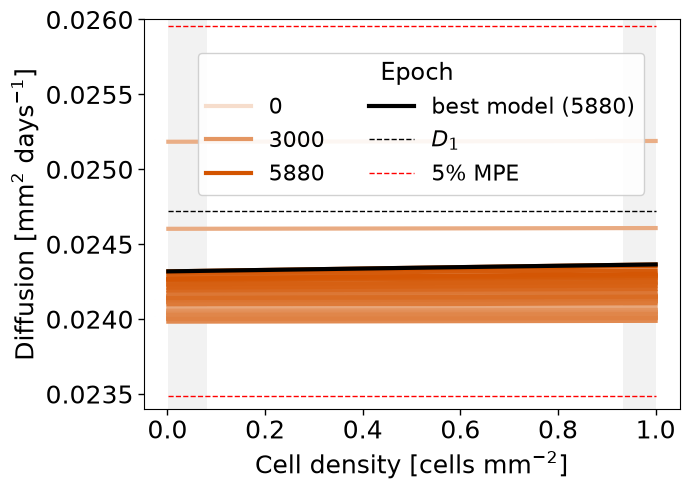

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_10000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png
-------------------------- Wu = 64 --------------------------- 
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_10000.0_diffusion_group_1_model0_ylim_0p015_0p11.png


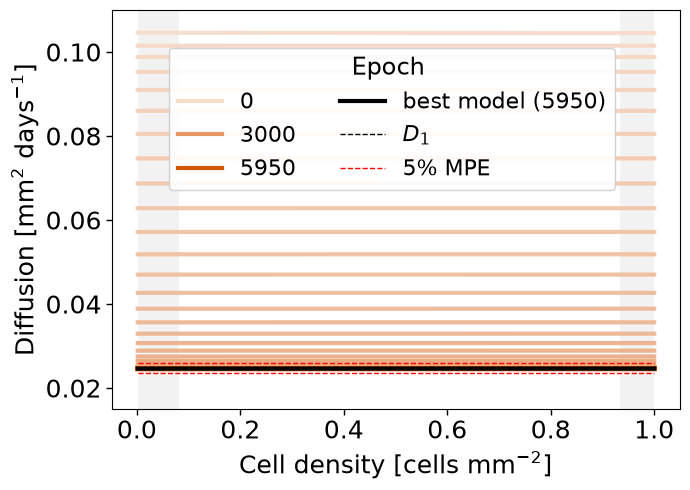

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_10000.0_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_10000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png


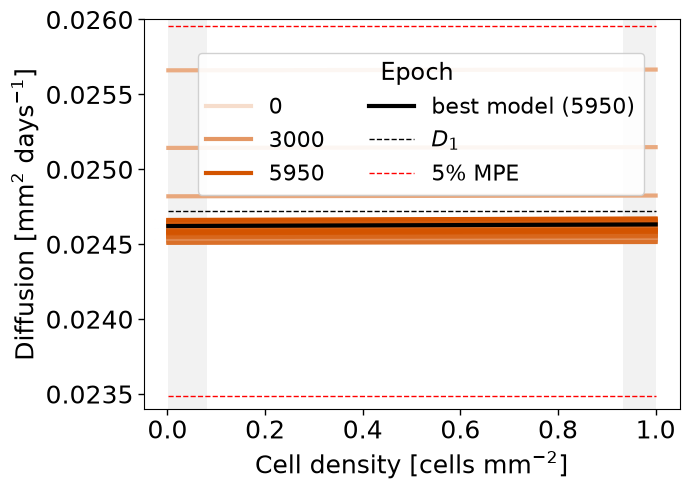

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_10000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png
============================================================== 1000000.0 ============================================================== 
-------------------------- Wu = 16 --------------------------- 
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_1000000.0_diffusion_group_1_model0_ylim_0p015_0p11.png


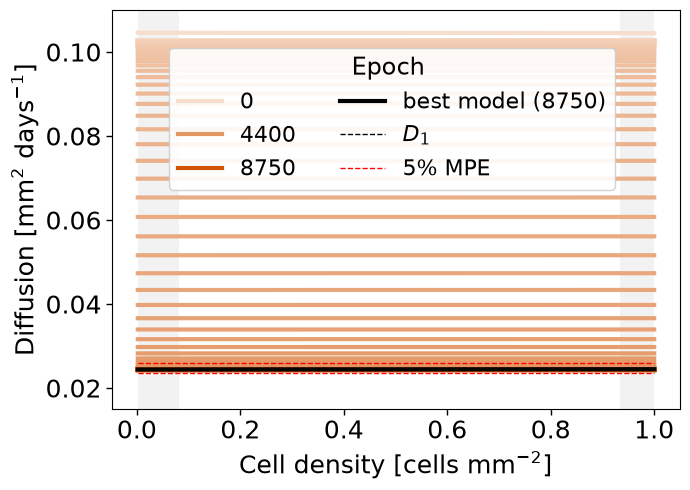

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_1000000.0_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_1000000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png


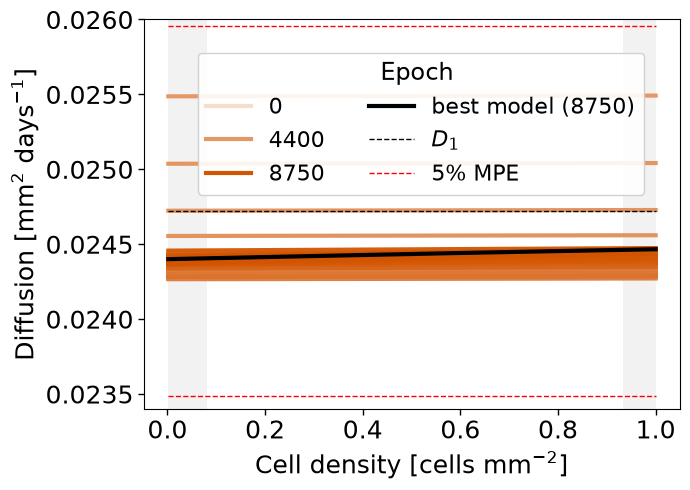

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu16_D_mono_weight_1000000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png
-------------------------- Wu = 64 --------------------------- 
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_1000000.0_diffusion_group_1_model0_ylim_0p015_0p11.png


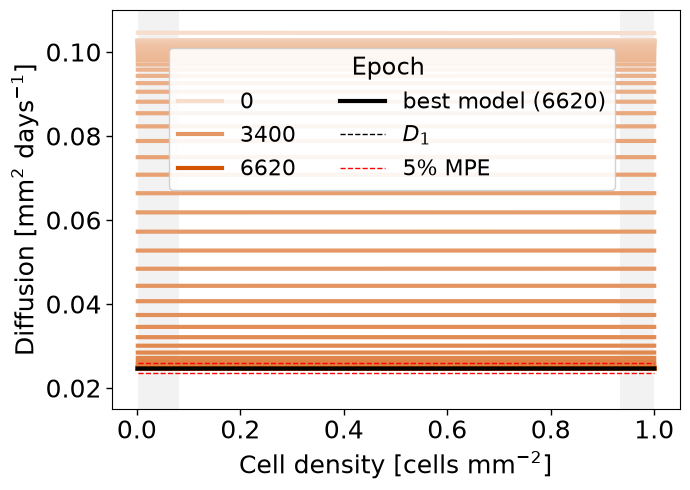

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_1000000.0_diffusion_group_1_model0_ylim_0p015_0p11.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_1000000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png


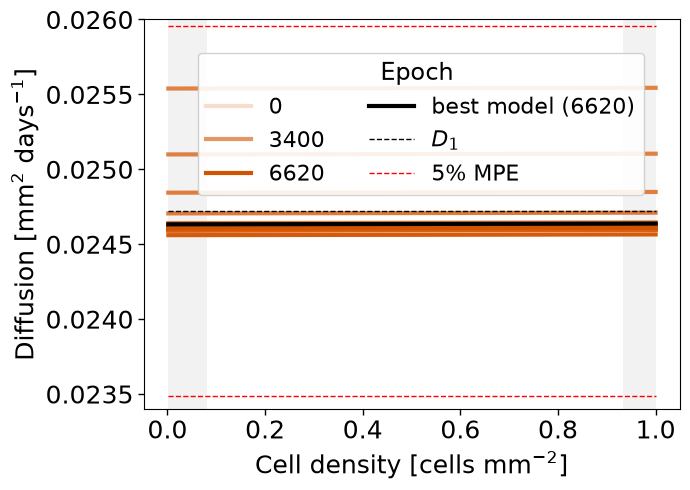

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS4/Wu64_D_mono_weight_1000000.0_diffusion_group_1_model0_ylim_0p0234_0p026.png


In [8]:
# Figure S4: diffusion evolution across epochs for each monotonicity-weight setting.
  
for D_mono_weight_case in D_mono_weight_values:
    
    print(f"============================================================== {D_mono_weight_case} ============================================================== ")
    binn_models_by_ES_case = load_models_for_D_mono_weight(D_mono_weight_case)
    varyES_models_chosen_ES_case = binn_models_by_ES_case[binn_ES_list[0]]
    varyES_models_chosen_D_case = varyES_models_chosen_ES_case[D_NN_chosen]
    varyES_models_by_ES_chosen_D_case = [
        binn_models_by_ES_case[ES][D_NN_chosen] for ES in binn_ES_list
    ]
    plot_params_diff_case = plot_params_from_models(
        varyES_models_chosen_D_case,
        D_COLORS,
    )

    for Wu in u_NN_lst:
        print(f"-------------------------- Wu = {Wu} --------------------------- ")
        plot_settings = {
            "name": str(
                name_intro_figS4
                / f"Wu{Wu}_D_mono_weight_{D_mono_weight_case}.png"
            ),
            "fill": True,
            "line_width": 2,
            "legends": [
                {
                    "loc": (0.1, 0.55),
                    "fontsize": 16,
                    "ncols": 2,
                    "framealpha": 0.9,
                },
                {
                    "loc": (0.1, 0.55),
                    "fontsize": 16,
                    "ncols": 2,
                    "framealpha": 0.9,
                },
            ],
            "xaxis": {"min": 0, "max": 1e3, "break": 1e1},
            "line_lengths": {"hlength": 7.5e3, "vlength_factor": 2},
            "line_widths_on_axis": {"hwidth": 2, "vwidth": 2},
            "fontsizes": AXIS_FONTSIZES,
            "figsize": figsize,
            "y_lims": [(0.015, 0.11), (0.0234, 0.026)],
            "mpe": 5,
            "epoch_step": 10,
            "epoch_sf": 10,
            "D_true_label": r"$D_1$",
        }

        plot_diffusion_across_epochs(
            overwrite=True,
            models_dics_list=[varyES_models_by_ES_chosen_D_case[0][Wu]],
            plot_params=plot_params_diff_case,
            plot_settings=plot_settings,
            seed_index=0,
            shade_outside_central_90=True,
        )




## 5. Reusable helper for additional constraint-weight scenarios

The next helper cell generalises the plotting workflow so that explicit `(D_bound_weight, D_mono_weight)` combinations can be rendered with the same publication settings and saved either with descriptive filenames or figure-panel labels.

In [9]:
# Reusable helper surface for additional constraint-weight scenarios.
def load_case1_models_for_constraint_weights(D_bound_weight_case, D_mono_weight_case, allConstraints_case=False):
    constraint_weights_case = {
        "D_bound_weight": D_bound_weight_case,
        "D_mono_weight": D_mono_weight_case,
        "G_bound_weight": 1e4,
        "G_mono_weight": 1e4,
    }

    fixed_filters_case = {
        "dataX1num": xNum,
        "dataX2num": dataX2num,
        "dataTnum": tNum,
        "dataK": K,
        "dataICLabel": IC_label,
        "dataDiffLabel": diff_label,
        "dataGrowLabel": grow_label,
        "dataGamma": gamma,
        "dataNoisePercent": noise_percent,
        "dataNoiseSeed": seed,
        "binnVF": binnVF,
        "binnGenerateIndicesLabel": binnGenerateIndicesLabel,
        "binnGsize": FIXED_G_WIDTH,
        "DoneParamBool": D_one_param_bool,
        "binnDevice": binnDevice,
        "allConstraints": allConstraints_case,
        **({"constraintTuple": CONSTRAINT_TUPLE} if allConstraints_case else {}),
        **({
            key: constraint_weights_case[key]
            for enabled, key in zip(
                CONSTRAINT_TUPLE,
                ("D_bound_weight", "D_mono_weight", "G_bound_weight", "G_mono_weight"),
            )
            if enabled
        } if allConstraints_case else {}),
        **({
            key: CONSTRAINT_BOUNDS[key]
            for enabled, key in zip(
                CONSTRAINT_TUPLE,
                ("D_bound", None, "G_bound", None),
            )
            if enabled and key is not None
        } if allConstraints_case else {}),
        "BCbool": BCbool,
        "numPDEsamples": S12_NUM_PDE_SAMPLES,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelUpdateThresh": binn_rel_update_thresh,
        "binnRelSaveThresh": binn_rel_save_thresh,
    }

    binn_df_case = condense_df(binn_df, fixed_filters_case)
    if binn_df_case.empty:
        raise ValueError(
            f"No BINN models found for D_bound_weight={D_bound_weight_case}, "
            f"D_mono_weight={D_mono_weight_case}."
        )

    models_by_es_case = load_case1_models(
        es_values=binn_ES_list,
        d_sizes=D_NN_lst,
        u_sizes=u_NN_lst,
        split_seeds=binnSplitSeeds,
        fixed_filters_override=fixed_filters_case,
        model_df_override=binn_df_case,
    )

    return binn_df_case, models_by_es_case


def run_case1_weight_plots(
    D_bound_weight_case,
    D_mono_weight_case,
    scenario_settings,
    allConstraints_case=False,
    plots_to_run=None,
    output_dirs=None,
    output_names=None,
    seed_index=2,
    wu_values=None,
):
    plots_to_run = {
        "min_val": True,
        "min_MSE": True,
        "diagnostics_base": True,
        "diagnostics_adam": True,
        "diagnostics_Dnorm": True,
        "diffusion_across_epochs": True,
        **(plots_to_run or {}),
    }
    output_dirs = {
        "binn":  name_intro_figS2,
        "diff": name_intro_figS2,
        "diagnostics": name_intro_figS2,
        **(output_dirs or {}),
    }
    output_names = output_names or {}
    wu_values = u_NN_lst[:1] if wu_values is None else wu_values

    for output_dir in output_dirs.values():
        os.makedirs(output_dir, exist_ok=True)

    _, binn_models_by_ES_case = load_case1_models_for_constraint_weights(
        D_bound_weight_case=D_bound_weight_case,
        D_mono_weight_case=D_mono_weight_case,
        allConstraints_case=allConstraints_case,
    )

    varyES_models_chosen_ES_case = binn_models_by_ES_case[binn_ES_list[0]]
    varyES_models_chosen_D_case = varyES_models_chosen_ES_case[D_NN_chosen]
    varyES_models_by_ES_chosen_D_case = [
        binn_models_by_ES_case[ES][D_NN_chosen] for ES in binn_ES_list
    ]

    epoch_axis_case = {
        "min": minEpoch,
        "max": scenario_settings["maxEpoch"],
        "break": scenario_settings["breakEpoch"],
    }
    es_entries_case = [
        (str(ES), MARKER_STYLES[i % len(MARKER_STYLES)])
        for i, ES in enumerate(binn_ES_list)
    ]

    if plots_to_run["min_val"]:
        plot_params_val_case = plot_params_from_models(
            varyES_models_chosen_D_case,
            BLUE_COLORS,
        )

        plot_settings_val_case = {
            "name": str(
                output_names.get(
                    "min_val",
                    output_dirs["binn"]
                    / f"figA1_valLoss_bound{D_bound_weight_case}_grad{D_mono_weight_case}_Wu{u_NN_lst}.png",
                )
            ),
            "fill": True,
            "line_width": 2,
            "legend": copy.deepcopy(scenario_settings["val_legend"]),
            "xaxis": epoch_axis_case,
            "fontsizes": AXIS_FONTSIZES,
            "figsize": figsize,
            "ylabel": "Minimum validation loss [a.u]",
            "es_entries": es_entries_case,
        }

        plot_running_min_loss_component_broken_x_log_lst(
            models_dics_list=varyES_models_by_ES_chosen_D_case,
            loss_attr="val_loss_list",
            plot_params=plot_params_val_case,
            plot_settings=plot_settings_val_case
        )

    if plots_to_run["min_MSE"]:
        plot_params_diff_case = plot_params_from_models(
            varyES_models_chosen_D_case,
            D_COLORS,
        )

        plot_settings_diff_case = {
            "name": str(
                output_names.get(
                    "min_MSE",
                    output_dirs["diff"]
                    / f"figA1_diffMSE_bound{D_bound_weight_case}_grad{D_mono_weight_case}_Wu{u_NN_lst}.png",
                )
            ),
            "fill": True,
            "line_width": 2,
            "legend": copy.deepcopy(scenario_settings["diff_legend"]),
            "xaxis": epoch_axis_case,
            "fontsizes": AXIS_FONTSIZES,
            "figsize": figsize,
            "ylabel": "Minimum validation loss [a.u]",
            "es_entries": es_entries_case,
        }

        plot_running_min_MSE_diff_loss_broken_x_log_lst(
            models_dics_list=varyES_models_by_ES_chosen_D_case,
            plot_params=plot_params_diff_case,
            plot_settings=plot_settings_diff_case,
        )



    if plots_to_run["diffusion_across_epochs"]:
        plot_params_diff_case = plot_params_from_models(
            varyES_models_chosen_D_case,
            D_COLORS,
        )

        for wu_index, Wu in enumerate(wu_values):
            diffusion_plot_settings_case = copy.deepcopy(
                scenario_settings["diffusion_across_epochs"]
            )
            custom_diffusion_names = output_names.get(
                f"diffusion_across_epochs_{wu_index}",
                output_names.get("diffusion_across_epochs"),
            )
            diffusion_plot_settings_case["fontsizes"] = AXIS_FONTSIZES
            diffusion_plot_settings_case["figsize"] = figsize

            if isinstance(custom_diffusion_names, (list, tuple)):
                y_lims_case = list(diffusion_plot_settings_case.get("y_lims") or [])
                if len(custom_diffusion_names) != len(y_lims_case):
                    raise ValueError(
                        f"Expected {len(y_lims_case)} diffusion output names for Wu={Wu}, "
                        f"got {len(custom_diffusion_names)}."
                    )

                for y_lim_index, (custom_name, current_y_lim) in enumerate(
                    zip(custom_diffusion_names, y_lims_case)
                ):
                    diffusion_plot_settings_single_case = copy.deepcopy(
                        diffusion_plot_settings_case
                    )
                    diffusion_plot_settings_single_case["name"] = str(custom_name)
                    diffusion_plot_settings_single_case.pop("y_lims", None)
                    diffusion_plot_settings_single_case["y_lim"] = current_y_lim
                    os.makedirs(
                        Path(diffusion_plot_settings_single_case["name"]).parent,
                        exist_ok=True,
                    )

                    plot_diffusion_across_epochs(
                        overwrite=True,
                        models_dics_list=[varyES_models_by_ES_chosen_D_case[0][Wu]],
                        plot_params=plot_params_diff_case,
                        plot_settings=diffusion_plot_settings_single_case,
                        seed_index=seed_index,
                        shade_outside_central_90=True,
                    )
            else:
                diffusion_plot_settings_case["name"] = str(
                    custom_diffusion_names
                    if custom_diffusion_names is not None
                    else output_dirs["diff"]
                    / f"Wu{Wu}/figA1_bound{D_bound_weight_case}_grad{D_mono_weight_case}.png"
                )
                os.makedirs(Path(diffusion_plot_settings_case["name"]).parent, exist_ok=True)

                plot_diffusion_across_epochs(
                    overwrite=True,
                    models_dics_list=[varyES_models_by_ES_chosen_D_case[0][Wu]],
                    plot_params=plot_params_diff_case,
                    plot_settings=diffusion_plot_settings_case,
                    seed_index=seed_index,
                    shade_outside_central_90=True,
                )




## 6. Figure S2  combined-weight scenario

Combined `(D_bound_weight, D_mono_weight) = (1e4, 1e4)` and `(D_bound_weight, D_mono_weight) = (0, 0)` settings with the diagnostic-focused output selection used during figure development.

SORTED ['16', '64']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_a.png


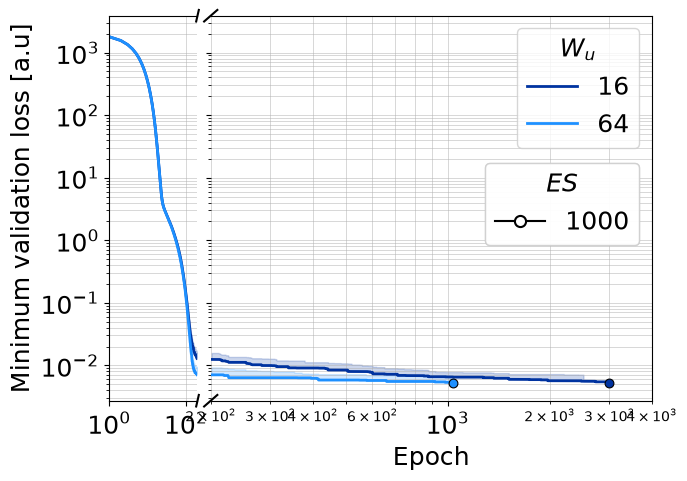

Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_d_16_1_diffusion_group_1_model0.png


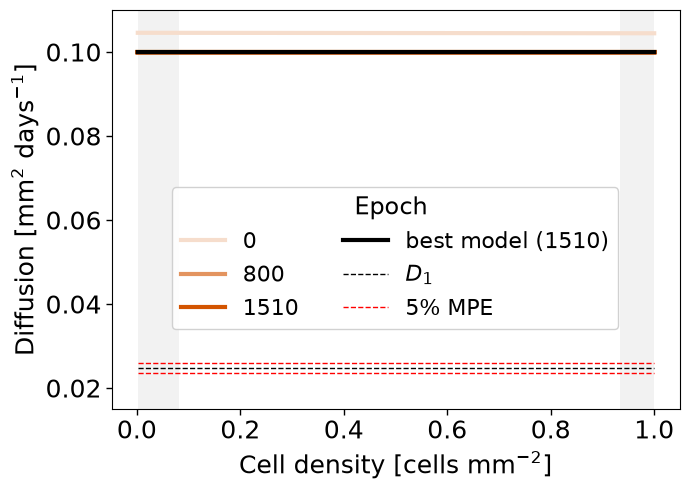

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_d_16_1_diffusion_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_d_16_2_diffusion_group_1_model0.png


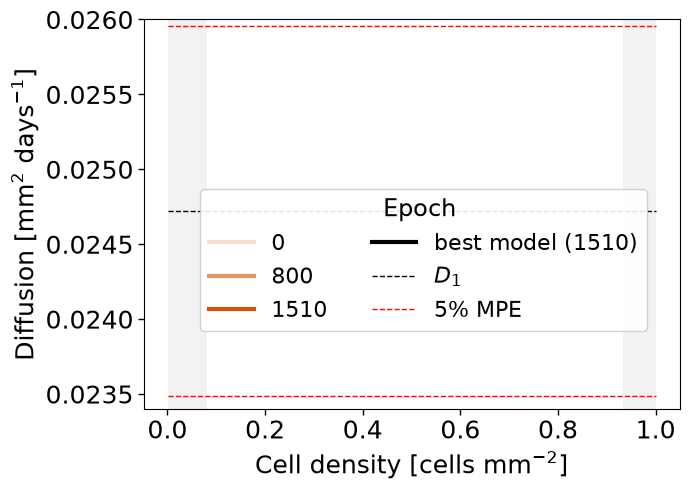

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_d_16_2_diffusion_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_d_64_1_diffusion_group_1_model0.png


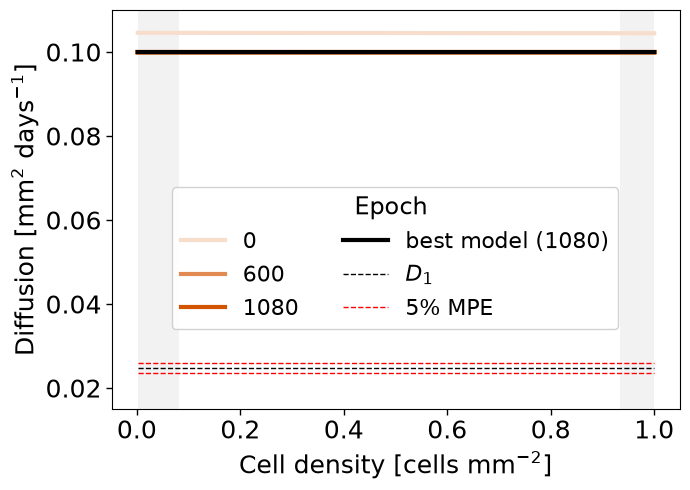

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_d_64_1_diffusion_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_d_64_2_diffusion_group_1_model0.png


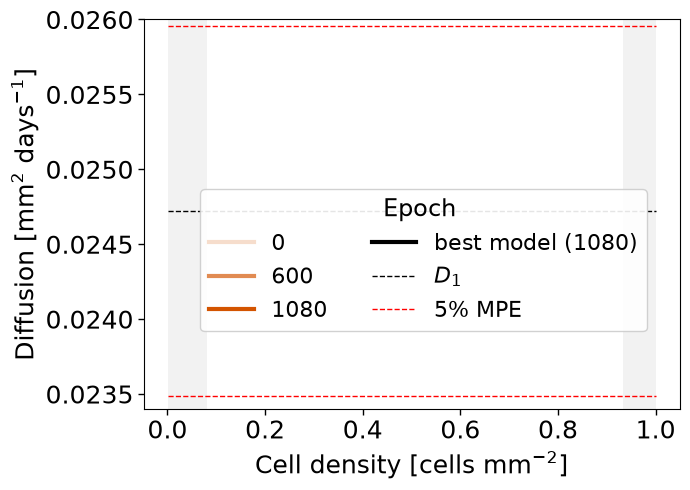

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_d_64_2_diffusion_group_1_model0.png


In [10]:
combined_weight_plot_root = name_intro_figS2
combined_weight_output_names = {
    "min_val": combined_weight_plot_root / "plot_a.png",
    "diagnostics_adam": combined_weight_plot_root / "plot_b.png",
    "diagnostics_Dnorm": combined_weight_plot_root / "plot_c.png",
    "diffusion_across_epochs_0": [
        combined_weight_plot_root / "plot_d_16_1.png",
        combined_weight_plot_root / "plot_d_16_2.png",
    ],
    "diffusion_across_epochs_1": [
        combined_weight_plot_root / "plot_d_64_1.png",
        combined_weight_plot_root / "plot_d_64_2.png",
    ],
}

combined_weight_plot_settings = {
    # Retune these in one place for the combined `(D_bound_weight, D_mono_weight) = (1e4, 1e4)` case.
    "maxEpoch": 4e3,
    "breakEpoch": 2e2,
    "val_legend": {
        "panel": 2,
        "loc": (1, 1),
        "loc_upd": (1, 0.65),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
    },
    "diagnostics_x_max": 5e3,
    "diffusion_across_epochs": {
        "fill": True,
        "line_width": 2,
        "legends": [
            {
              "loc": (0.105, 0.2),
                "fontsize": 16,
                "ncols": 2,
                "framealpha": 0.9,
            },
            {
              "loc": (0.0105, 0.2),
                "fontsize": 16,
                "ncols": 2,
                "framealpha": 0.9,
            },
        ],
        "xaxis": {"min": 0, "max": 1e3, "break": 1e1},
        "line_lengths": {"hlength": 7.5e3, "vlength_factor": 2},
        "line_widths_on_axis": {"hwidth": 2, "vwidth": 2},
        "y_lims": [(0.015, 0.11), (0.0234, 0.026)],
        "mpe": 5,
        "epoch_step": 10,
        "epoch_sf": 10,
         "D_true_label": r"$D_1$",
    },
}

run_case1_weight_plots(
    D_bound_weight_case=1e4,
    D_mono_weight_case=1e4,
    scenario_settings=combined_weight_plot_settings,
    allConstraints_case=True,
    plots_to_run={
        "min_val": True,
        "min_MSE": False,
        "diagnostics_base": False,
        "diagnostics_adam": True,
        "diagnostics_Dnorm": True,
        "diffusion_across_epochs": True,
    },
    output_names=combined_weight_output_names,
    wu_values=[16, 64]
)




SORTED ['16', '64']


/Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/paper_helpers/plotting_loss_running_min.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_e.png


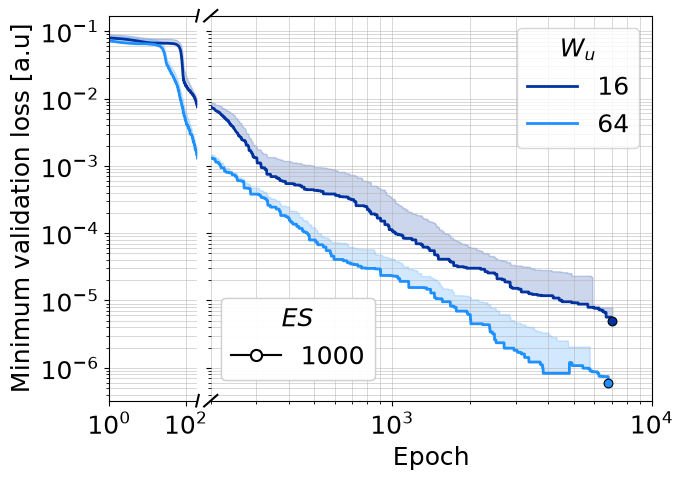

Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_h_16_1_diffusion_group_1_model0.png


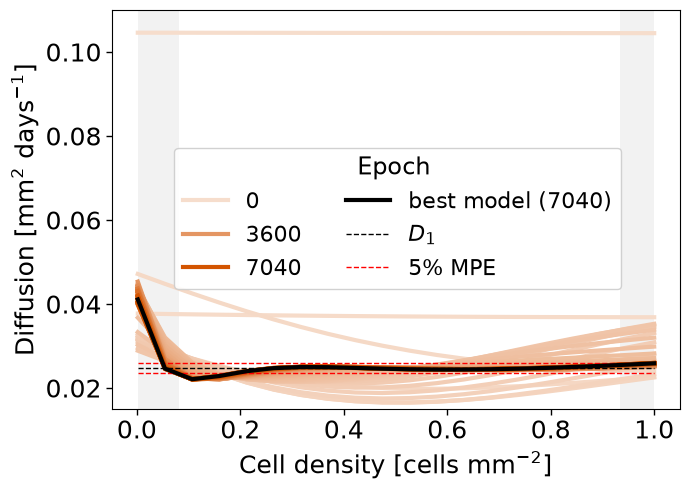

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_h_16_1_diffusion_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_h_16_2_diffusion_group_1_model0.png


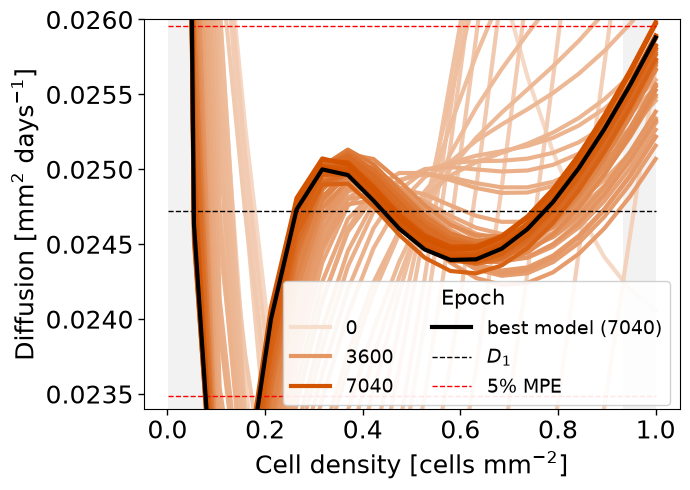

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_h_16_2_diffusion_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_h_64_1_diffusion_group_1_model0.png


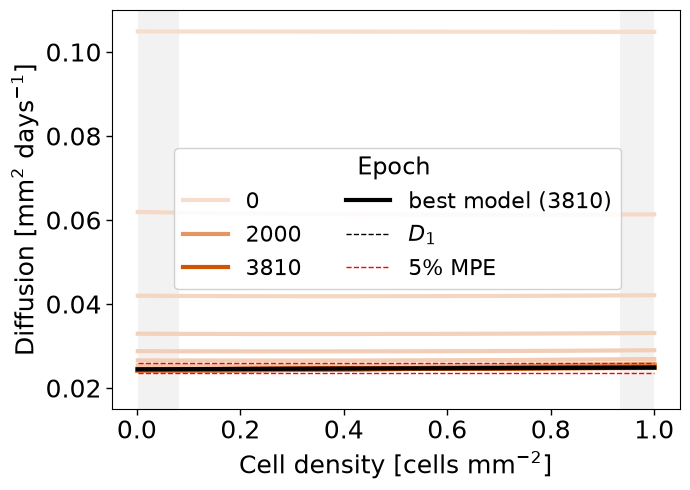

Saved diffusion plot for group_1, model_index=0, y_lim=(0.015, 0.11): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_h_64_1_diffusion_group_1_model0.png
Overwriting existing diffusion plot: /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_h_64_2_diffusion_group_1_model0.png


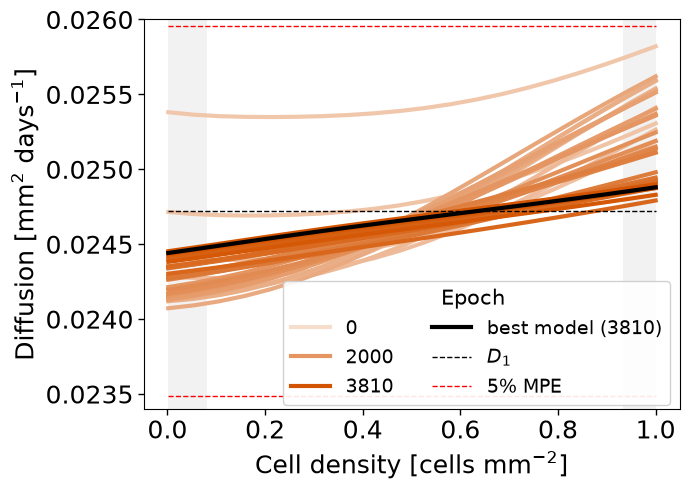

Saved diffusion plot for group_1, model_index=0, y_lim=(0.0234, 0.026): /Users/willa954/Desktop/Git-personal/Hyperparam/hyperparam-selection/Training/JN/pngs/1D/case1/figS2/plot_h_64_2_diffusion_group_1_model0.png


In [11]:
combo_weight_plot_root = JN_ROOT / "pngs" / "1D" / "case1" / "figS2"
combo_output_dirs = {
    "binn": combo_weight_plot_root,
    "diff": combo_weight_plot_root,
    "diagnostics": combo_weight_plot_root,
}
for output_dir in combo_output_dirs.values():
    os.makedirs(output_dir, exist_ok=True)

combo_output_names = {
    "min_val": combo_weight_plot_root / "plot_e.png",
    "diagnostics_adam": combo_weight_plot_root / "plot_f.png",
    "diagnostics_Dnorm": combo_weight_plot_root / "plot_g.png",
    "diffusion_across_epochs_0": [
        combo_weight_plot_root / "plot_h_16_1.png",
        combo_weight_plot_root / "plot_h_16_2.png",
    ],
    "diffusion_across_epochs_1": [
        combo_weight_plot_root / "plot_h_64_1.png",
        combo_weight_plot_root / "plot_h_64_2.png",
    ],
}

combo_bound_mono_plot_settings = {
    "maxEpoch": 1e4,
    "breakEpoch": 2e2,
    "val_legend": {
        "panel": 2,
        "loc": (1, 1),
        "loc_upd": (0.4, 0.3),
        "fontsize": LEGEND_SIZE,
        "ncols": 1,
    },
    "diagnostics_x_max": 1e4,
    "diffusion_across_epochs": {
        "fill": True,
        "line_width": 2,
        "legends": {
            (0.015, 0.11): {
                "loc": (0.11, 0.3),
                "fontsize": 16,
                "ncols": 2,
                "framealpha": 0.9,
            },
            (0.0234, 0.026): {
                "loc": (0.26, 0.01),
                "fontsize": 14,
                "ncols": 2,
                "framealpha": 0.9,
            },
        },

        "y_lims": [(0.015, 0.11), (0.0234, 0.026)],
        "mpe": 5,
        "epoch_step": 10,
        "epoch_sf": 10,
         "D_true_label": r"$D_1$",
    },
}

run_case1_weight_plots(
    D_bound_weight_case=0,
    D_mono_weight_case=0,
    scenario_settings=combo_bound_mono_plot_settings,
    allConstraints_case=True,
    plots_to_run={
        "min_val": True,
        "min_MSE": False,
        "diagnostics_base": False,
        "diagnostics_adam": True,
        "diagnostics_Dnorm": True,
        "diffusion_across_epochs": True,
    },
    output_dirs=combo_output_dirs,
    output_names=combo_output_names,
    seed_index=0,
    wu_values=[16, 64]
)




## References

J. H. Lagergren et al. "Biologically-informed neural networks guide mechanistic modeling from sparse experimental data". In: *PLoS Comput Biol* 16.12 (2020), e1008462. DOI: [10.1371/journal.pcbi.1008462](https://doi.org/10.1371/journal.pcbi.1008462).
